## 0. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

## 1. Tải và khám phá dữ liệu


In [2]:
from google.colab import files

uploaded = files.upload()
import pandas as pd

df = pd.read_csv("coffee_value_benchmark.csv")

Saving coffee_value_benchmark.csv to coffee_value_benchmark.csv


In [3]:
print(df.shape)    # số dòng, số cột
print()
print()
print(df.info())
print()
print()   # thông tin cột
print(df.head())   # 5 dòng đầu tiên



(35700, 36)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35700 entries, 0 to 35699
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               35700 non-null  object 
 1   lot_id                  35700 non-null  object 
 2   harvest_season          35700 non-null  object 
 3   harvest_calendar_year   35700 non-null  int64  
 4   harvest_month           35700 non-null  int64  
 5   country_of_origin       35700 non-null  object 
 6   farm_type               35700 non-null  object 
 7   farm_size_hectares      35700 non-null  float64
 8   tree_age_years          35700 non-null  float64
 9   altitude_mean_meters    35700 non-null  float64
 10  species                 35700 non-null  object 
 11  avg_temp_c              35700 non-null  float64
 12  avg_annual_rainfall_mm  33881 non-null  float64
 13  humidity_pct            33418 non-null  float64
 14  processing_method       

### 📝 TODO 1.1 - Thống kê mô tả
In ra: thông tin DataFrame, thống kê mô tả các cột số, số mẫu mỗi lớp, số giá trị thiếu mỗi cột.

*Gợi ý:* `df.info()`, `df.describe()`, `df["species"].value_counts()`, `df.isnull().sum()`

In [4]:
# ========== BẮT ĐẦU CODE CỦA BẠN ==========
# Viết code tại đây

print("Thông tin DataFrame")
print(df.info())
print()
print()

print("Thống kê mô tả")
print(df.describe())
print()
print()

print("Số mẫu mỗi lớp")
print(df["species"].value_counts())
print()
print()


print("Số giá trị thiếu mỗi cột")
print(df.isnull().sum())
print()
print()

# ========== KẾT THÚC CODE CỦA BẠN ==========

Thông tin DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35700 entries, 0 to 35699
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               35700 non-null  object 
 1   lot_id                  35700 non-null  object 
 2   harvest_season          35700 non-null  object 
 3   harvest_calendar_year   35700 non-null  int64  
 4   harvest_month           35700 non-null  int64  
 5   country_of_origin       35700 non-null  object 
 6   farm_type               35700 non-null  object 
 7   farm_size_hectares      35700 non-null  float64
 8   tree_age_years          35700 non-null  float64
 9   altitude_mean_meters    35700 non-null  float64
 10  species                 35700 non-null  object 
 11  avg_temp_c              35700 non-null  float64
 12  avg_annual_rainfall_mm  33881 non-null  float64
 13  humidity_pct            33418 non-null  float64
 14  processing_method 

## 2. Trực quan hóa dữ liệu

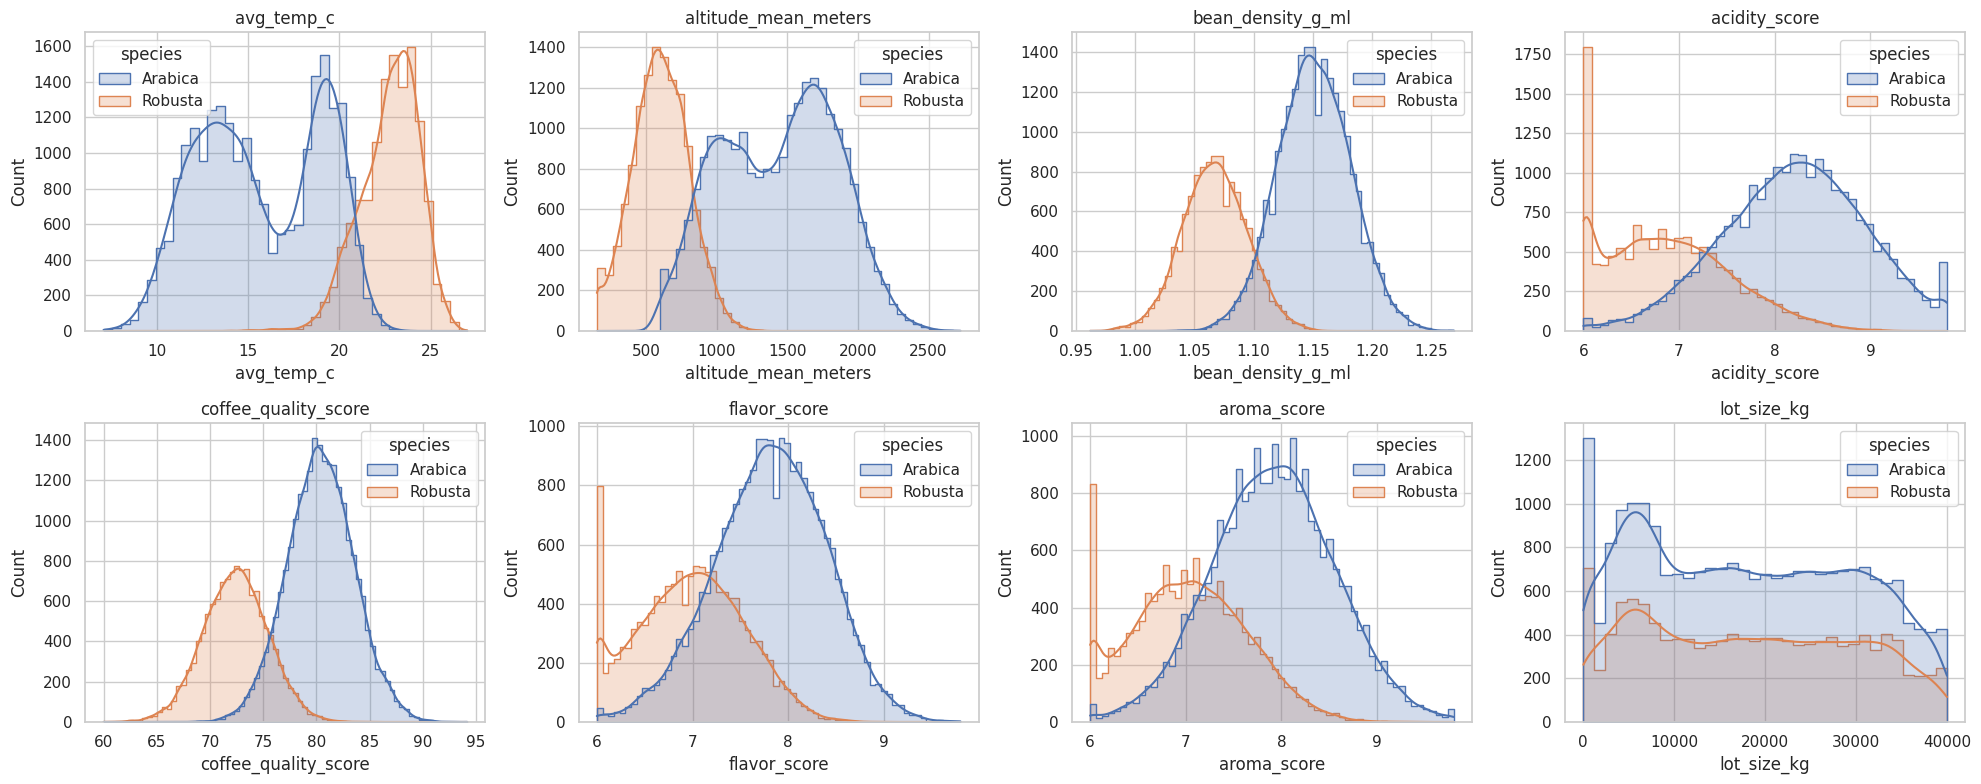

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define feature_names and class_names for the coffee dataset
feature_names = ['avg_temp_c', 'altitude_mean_meters', 'bean_density_g_ml', 'acidity_score', 'coffee_quality_score', 'flavor_score', 'aroma_score', 'lot_size_kg']
class_names = df['species'].unique()

# Phân phối từng đặc trưng theo lớp
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.ravel(), feature_names):
    sns.histplot(data=df, x=col, hue="species", kde=True, element="step", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

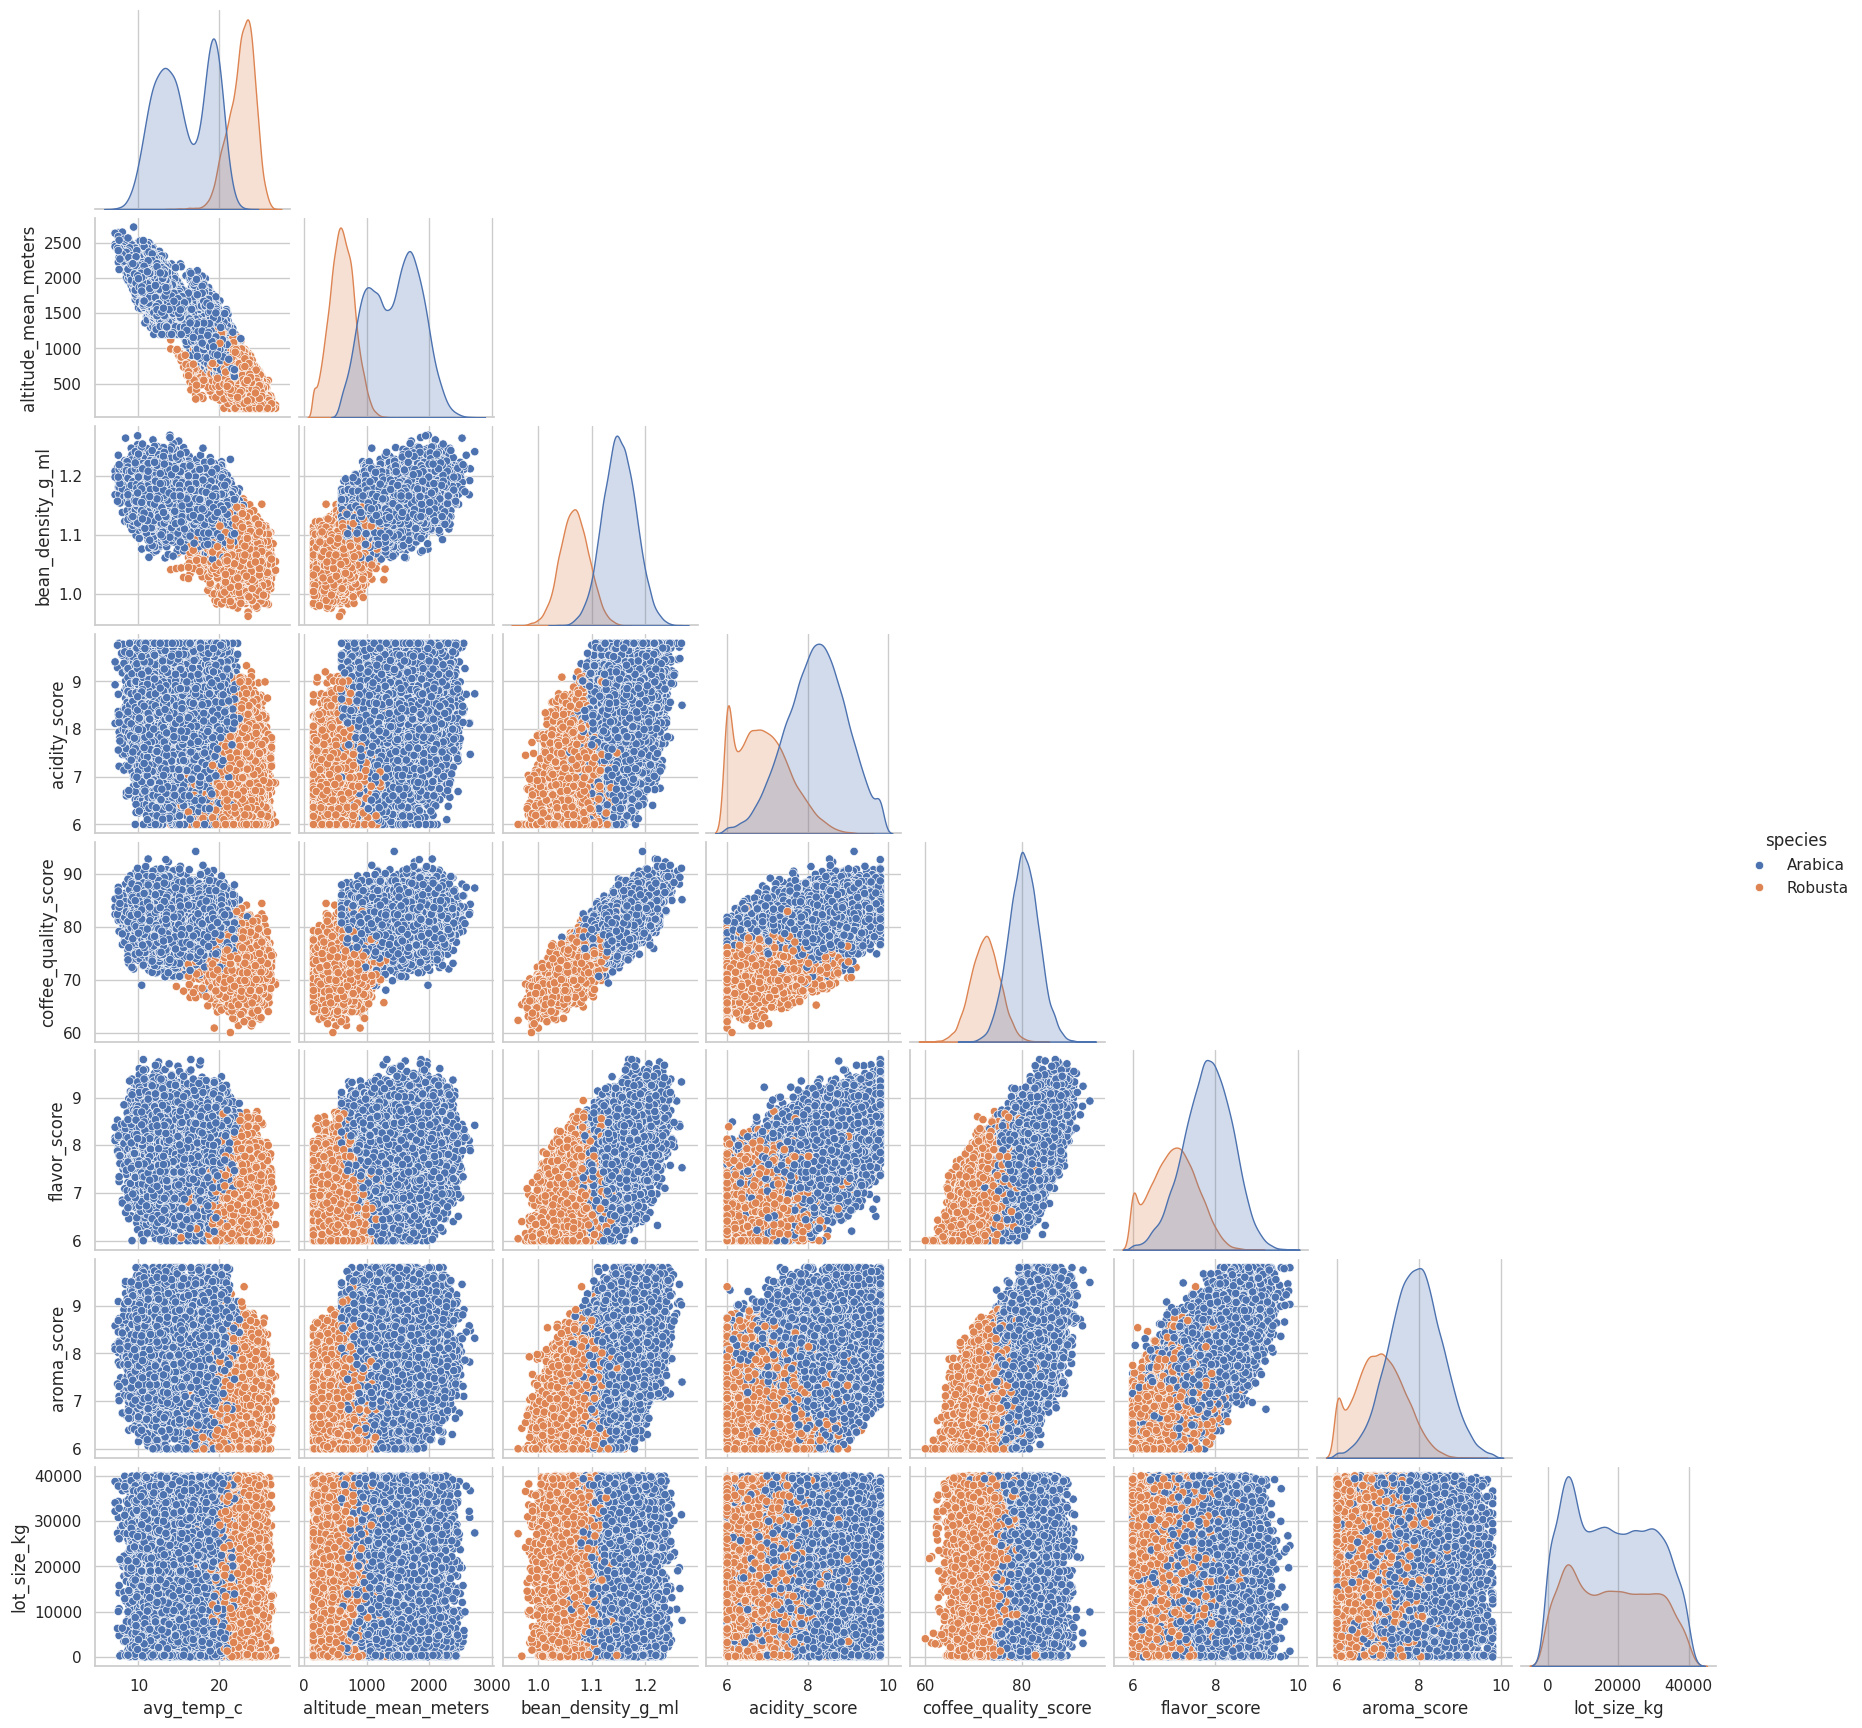

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Biểu đồ cặp (pairplot): quan hệ giữa từng cặp đặc trưng
sns.pairplot(df[feature_names + ['species']], hue="species", corner=True, height=2.2)
plt.show()

### 📝 TODO 2.1 - Ma trận tương quan
Vẽ heatmap ma trận tương quan giữa 4 đặc trưng (hiển thị giá trị, 2 chữ số thập phân).

*Gợi ý:* `df[feature_names].corr()`, `sns.heatmap(..., annot=True, fmt=".2f", cmap="coolwarm")`

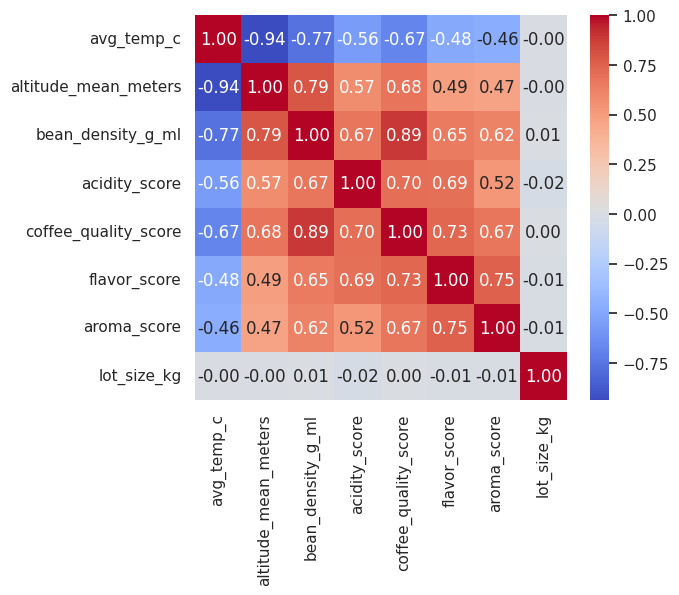

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
# ========== BẮT ĐẦU CODE CỦA BẠN ==========
corr = df[feature_names].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
# ========== KẾT THÚC CODE CỦA BẠN ==========
plt.show()

## 3. Tiền xử lý dữ liệu

Bài toán: **dự đoán giá cà phê** `price_usd_per_kg` (hồi quy) từ các đặc trưng về vùng trồng, quy trình chế biến, điều kiện bảo quản và điểm chất lượng.

Các bước: làm sạch → mã hóa one-hot biến phân loại → chia train/test và điền giá trị thiếu → chuẩn hóa.

### 📝 TODO 3.1 - Làm sạch dữ liệu
Từ kết quả khảo sát ở phần 1 và 2:
- `record_id`, `lot_id` là mã định danh, không có ý nghĩa dự đoán → không dùng làm đặc trưng.
- Có **700 `lot_id` bị lặp** (mỗi lot xuất hiện 2-3 lần, gần như giống hệt nhau). Nếu để nguyên, cùng một lot có thể nằm ở cả train lẫn test → **rò rỉ dữ liệu**, điểm test cao giả tạo. Giữ lại bản ghi đầu tiên của mỗi lot.
- `certification` thiếu ~61% (21.723 dòng). Nhóm thiếu có giá trung bình thấp nhất và tập trung ở phân khúc Commodity → hợp lý nếu hiểu là **"không có chứng nhận"**. Coi đây là một nhóm riêng (`"None"`) thay vì xóa dòng.
- `quality_grade` chỉ là bản chia nhóm của `coffee_quality_score` (mỗi hạng ứng với một khoảng điểm) → bỏ cho gọn.

*Gợi ý:* `df.drop_duplicates(subset=...)`, `Series.fillna(...)`, `df.select_dtypes(include=np.number)`

In [8]:
# ========== BẮT ĐẦU CODE CỦA BẠN ==========
TARGET_COL = "price_usd_per_kg"
ID_COLS = ["record_id", "lot_id"]
DERIVED_COLS = ["quality_grade"]

# (1) Loại bản ghi trùng lot_id
n_before = len(df)
df_clean = df.drop_duplicates(subset="lot_id", keep="first").copy()
print(f"Loại bản ghi trùng lot_id: {n_before} -> {len(df_clean)} dòng")

# (2) certification thiếu = không có chứng nhận
df_clean["certification"] = df_clean["certification"].fillna("None")

# (3) Tách cột số và cột phân loại (phân loại = mọi cột không phải số, không phải id/derived/target)
num_cols = [c for c in df_clean.select_dtypes(include=np.number).columns if c != TARGET_COL]
cat_cols = [c for c in df_clean.columns
            if c not in num_cols + ID_COLS + DERIVED_COLS + [TARGET_COL]]

print("Số cột số       :", len(num_cols))
print("Số cột phân loại:", len(cat_cols))
print()
print("Số giá trị khác nhau của mỗi cột phân loại:")
print(df_clean[cat_cols].nunique().to_string())
# ========== KẾT THÚC CODE CỦA BẠN ==========

Loại bản ghi trùng lot_id: 35700 -> 35000 dòng
Số cột số       : 21
Số cột phân loại: 11

Số giá trị khác nhau của mỗi cột phân loại:
harvest_season            5
country_of_origin         7
farm_type                 3
species                   2
processing_method         4
drying_method             3
storage_conditions        2
traceability_level        5
certification             5
intended_buyer_segment    3
roast_level               3


In [9]:
# ✅ Kiểm tra
assert df_clean["lot_id"].is_unique, "Vẫn còn lot_id trùng"
assert df_clean["certification"].isnull().sum() == 0
assert TARGET_COL not in num_cols and TARGET_COL not in cat_cols
print("OK")

OK


### 📝 TODO 3.2 - Mã hóa one-hot cho biến phân loại
Khác với bài Softmax (one-hot **nhãn** `y`), ở bài hồi quy nhãn là giá liên tục nên **không** one-hot `y`. One-hot được dùng cho **các đặc trưng dạng chữ** (`species`, `country_of_origin`, `processing_method`, ...): mỗi giá trị trở thành một cột 0/1.

Dùng `drop_first=True` để bỏ bớt một cột của mỗi nhóm, tránh đa cộng tuyến hoàn toàn với hệ số chặn $b$.

*Gợi ý:* `pd.get_dummies(df, columns=..., drop_first=True, dtype=float)`

> Việc one-hot toàn bộ dữ liệu trước khi chia chỉ dùng *tập các giá trị có thể có* của từng cột, không dùng thống kê của nhãn nên không gây rò rỉ dữ liệu.

In [10]:
# ========== BẮT ĐẦU CODE CỦA BẠN ==========
df_enc = pd.get_dummies(df_clean.drop(columns=ID_COLS + DERIVED_COLS),
                        columns=cat_cols, drop_first=True, dtype=float)

feature_names_all = [c for c in df_enc.columns if c != TARGET_COL]
X_df = df_enc[feature_names_all]
y = df_enc[TARGET_COL].values

print("Số đặc trưng sau one-hot:", len(feature_names_all))
print("Các cột one-hot của species:", [c for c in feature_names_all if c.startswith("species_")])
# ========== KẾT THÚC CODE CỦA BẠN ==========

Số đặc trưng sau one-hot: 52
Các cột one-hot của species: ['species_Robusta']


In [11]:
# ✅ Kiểm tra
onehot_cols = [c for c in feature_names_all if c not in num_cols]
assert set(np.unique(X_df[onehot_cols].values)) <= {0.0, 1.0}
assert len(feature_names_all) == len(num_cols) + len(onehot_cols)
print("OK - các cột one-hot chỉ chứa 0/1")

OK - các cột one-hot chỉ chứa 0/1


### 📝 TODO 3.3 - Chia tập train/test và điền giá trị thiếu
**(a)** Chia dữ liệu theo tỷ lệ 80/20 với `random_state=RANDOM_STATE`. **Không** dùng `stratify` (chỉ dành cho phân loại; ở đây nhãn là giá liên tục).

**(b)** Bốn cột số còn thiếu dữ liệu: `avg_annual_rainfall_mm` (1.819), `humidity_pct` (2.282), `moisture_pct` (1.612), `bean_density_g_ml` (1.632). Xóa dòng sẽ mất khoảng 18% dữ liệu nên ta **điền bằng median tính trên tập train**, rồi dùng đúng median đó cho tập test (cùng nguyên tắc "chỉ fit trên train" như chuẩn hóa, để tránh data leakage).

**(c)** Loại các cột có độ lệch chuẩn bằng 0 trên tập train (nếu có), vì chuẩn hóa sẽ chia cho 0.

In [12]:
# ========== BẮT ĐẦU CODE CỦA BẠN ==========
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=RANDOM_STATE)

# Điền thiếu bằng median của TẬP TRAIN
medians = X_train_df[num_cols].median()
X_train_df = X_train_df.fillna(medians)
X_test_df = X_test_df.fillna(medians)

# Bỏ cột hằng số trên tập train (nếu có)
keep = X_train_df.std() > 0
X_train_df, X_test_df = X_train_df.loc[:, keep], X_test_df.loc[:, keep]
feature_names_all = list(X_train_df.columns)

X_train, X_test = X_train_df.values, X_test_df.values

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Giá trị thiếu còn lại:", np.isnan(X_train).sum() + np.isnan(X_test).sum())
print("Giá trung bình  train / test:", round(y_train.mean(), 3), "/", round(y_test.mean(), 3))
# ========== KẾT THÚC CODE CỦA BẠN ==========

Train: (28000, 52) | Test: (7000, 52)
Giá trị thiếu còn lại: 0
Giá trung bình  train / test: 4.821 / 4.775


In [13]:
# ✅ Kiểm tra
assert X_train.shape[0] + X_test.shape[0] == len(df_clean)
assert X_train.shape[1] == X_test.shape[1] == len(feature_names_all)
assert abs(X_test.shape[0] / len(df_clean) - 0.2) < 0.01
assert not np.isnan(X_train).any() and not np.isnan(X_test).any(), "Vẫn còn giá trị thiếu"
print("OK")

OK


### 📝 TODO 3.4 - Chuẩn hóa (Standardization)

Công thức: $x' = \dfrac{x - \mu}{\sigma}$, trong đó $\mu, \sigma$ là trung bình và độ lệch chuẩn **tính trên tập train**.

> Lưu ý quan trọng: chỉ `fit` (tính $\mu, \sigma$) trên tập train, sau đó dùng chính $\mu, \sigma$ này để biến đổi tập test. Nếu tính trên toàn bộ dữ liệu sẽ gây **rò rỉ dữ liệu (data leakage)**.

**(a) Tự cài đặt** bằng NumPy (dùng `np.std` mặc định `ddof=0`, xử lý trường hợp $\sigma = 0$).

Với bài hồi quy, ta chuẩn hóa thêm cả **nhãn `y`** (giá) bằng $\mu_y, \sigma_y$ của tập train để Gradient Descent ổn định hơn. Khi báo cáo RMSE/MAE, nhớ đổi ngược về USD/kg: `y_pred = y_pred_s * sigma_y + mu_y`.

In [14]:
def standardize_fit(X):
    # Trả về mu, sigma: mảng kích thước (n_features,)
    # ========== BẮT ĐẦU CODE CỦA BẠN ==========
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    # Xử lý trường hợp sigma = 0
    sigma = np.where(sigma == 0, 1.0, sigma)
    return mu, sigma
    # ========== KẾT THÚC CODE CỦA BẠN ==========

def standardize_transform(X, mu, sigma):
    # ========== BẮT ĐẦU CODE CỦA BẠN ==========
    return (X - mu) / sigma
    # ========== KẾT THÚC CODE CỦA BẠN ==========

mu, sigma = standardize_fit(X_train)
X_train_s = standardize_transform(X_train, mu, sigma)
X_test_s = standardize_transform(X_test, mu, sigma)

# Chuẩn hóa nhãn y (tính trên train)
mu_y, sigma_y = y_train.mean(), y_train.std()
y_train_s = (y_train - mu_y) / sigma_y
y_test_s = (y_test - mu_y) / sigma_y

print("mu[:5]   :", np.round(mu[:5], 3))
print("sigma[:5]:", np.round(sigma[:5], 3))
print("mu_y:", round(mu_y, 3), "| sigma_y:", round(sigma_y, 3))

mu[:5]   : [2021.469    8.108   16.698   15.146 1144.348]
sigma[:5]: [  1.281   3.223  37.884   8.013 530.747]
mu_y: 4.821 | sigma_y: 2.209


**(b) Dùng thư viện** `StandardScaler` và so sánh với kết quả tự cài đặt.

In [15]:
# ========== BẮT ĐẦU CODE CỦA BẠN ==========
scaler = StandardScaler()
X_train_sk = scaler.fit_transform(X_train)
X_test_sk = scaler.transform(X_test)
# ========== KẾT THÚC CODE CỦA BẠN ==========

In [16]:
# ✅ Kiểm tra
assert np.allclose(X_train_s, X_train_sk) and np.allclose(X_test_s, X_test_sk)
assert np.allclose(X_train_s.mean(axis=0), 0) and np.allclose(X_train_s.std(axis=0), 1)
assert np.isclose(y_train_s.mean(), 0) and np.isclose(y_train_s.std(), 1)
print("OK - Tự cài đặt khớp với StandardScaler")
print("Trung bình tập TEST sau chuẩn hóa (5 cột đầu):", np.round(X_test_s.mean(axis=0)[:5], 3), "(không đúng bằng 0 là bình thường)")

OK - Tự cài đặt khớp với StandardScaler
Trung bình tập TEST sau chuẩn hóa (5 cột đầu): [ 0.007 -0.027 -0.015 -0.007  0.009] (không đúng bằng 0 là bình thường)


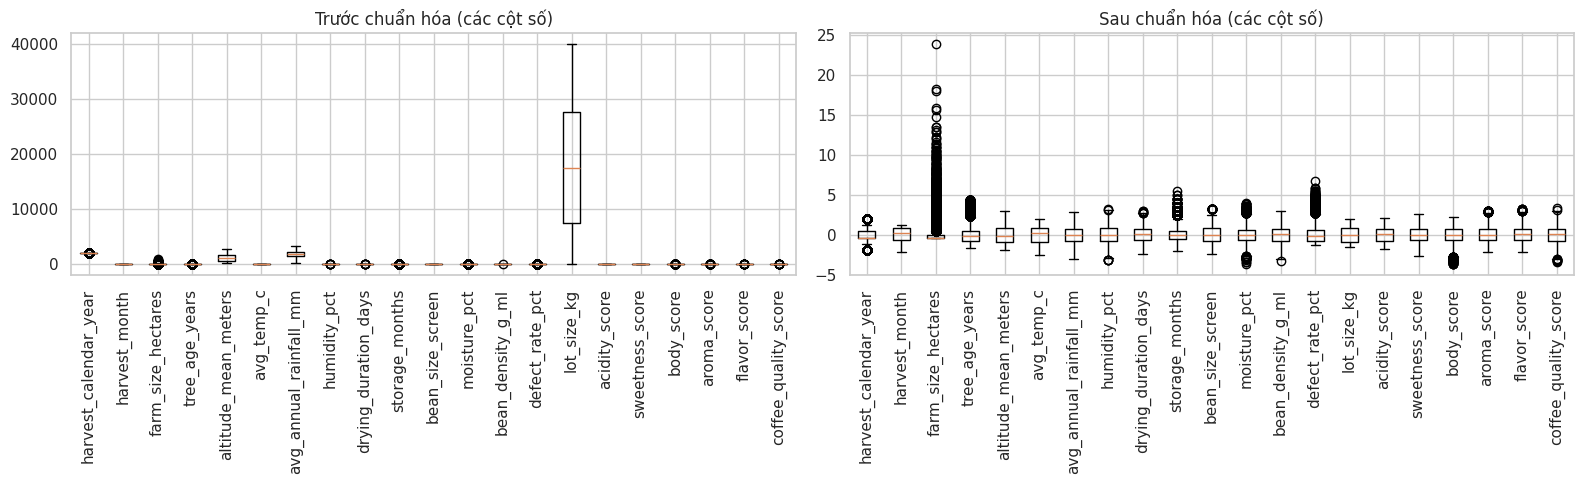

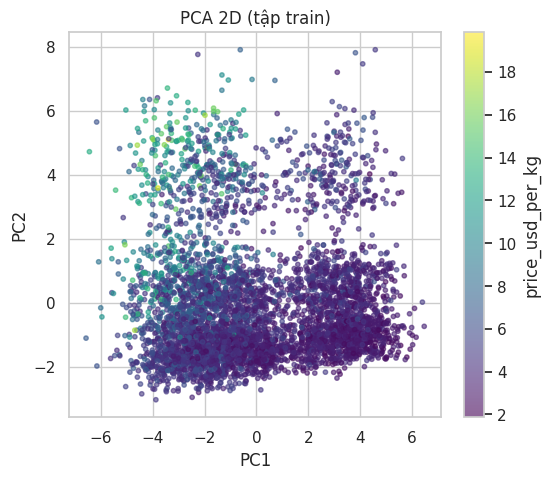

In [17]:
# So sánh trước và sau chuẩn hóa (chỉ vẽ các cột số; các cột one-hot vốn đã là 0/1)
num_idx = [i for i, c in enumerate(feature_names_all) if c in num_cols]
num_names = [feature_names_all[i] for i in num_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].boxplot(X_train[:, num_idx], tick_labels=num_names)
axes[0].set_title("Trước chuẩn hóa (các cột số)")
axes[1].boxplot(X_train_s[:, num_idx], tick_labels=num_names)
axes[1].set_title("Sau chuẩn hóa (các cột số)")
for ax in axes:
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

# Chiếu dữ liệu train đã chuẩn hóa xuống 2 chiều bằng PCA, tô màu theo GIÁ (mẫu 5000 điểm)
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X_train_s), size=min(5000, len(X_train_s)), replace=False)
X_pca = PCA(n_components=2).fit_transform(X_train_s[idx])
plt.figure(figsize=(6, 5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train[idx], cmap="viridis", s=10, alpha=0.6)
plt.colorbar(sc, label=TARGET_COL)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA 2D (tập train)")
plt.show()

### Thí nghiệm 3.5 - Phân phối của giá và biến đổi log
Giá lệch phải khá nặng (trung bình 4.81 > trung vị 4.18, giá cao nhất 22.85). Biến đổi $\log(1+y)$ giúp phân phối cân đối hơn. Thử nghiệm nhanh bằng `LinearRegression` của sklearn cho thấy R² trên tập test tăng từ khoảng 0.88 lên khoảng 0.91 khi huấn luyện trên giá đã log. Nếu phần mô hình dùng log thì phải đổi ngược dự đoán bằng `np.expm1`.

Độ lệch (skew) của giá - train: 2.33 | sau log1p: 1.13


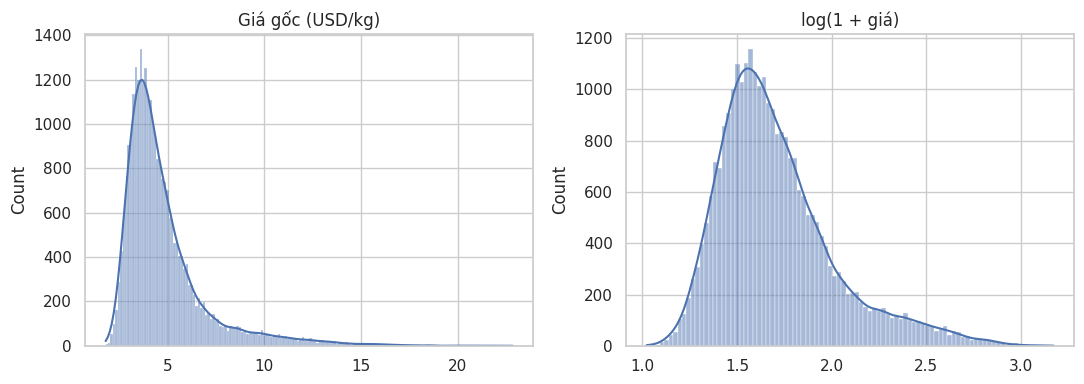

In [18]:
print("Độ lệch (skew) của giá - train:", round(pd.Series(y_train).skew(), 2),
      "| sau log1p:", round(pd.Series(np.log1p(y_train)).skew(), 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(y_train, kde=True, ax=axes[0]); axes[0].set_title("Giá gốc (USD/kg)")
sns.histplot(np.log1p(y_train), kde=True, ax=axes[1]); axes[1].set_title("log(1 + giá)")
plt.tight_layout()
plt.show()

## 4. Hồi quy Linear - Tự cài đặt bằng NumPy

**Mô hình:** với $X \in \mathbb{R}^{m \times n}$, $W \in \mathbb{R}^{n \times 1}$, $b \in \mathbb{R}^{1 \times 1}$:

$$\hat{Y} = XW + b$$

**Hàm mất mát Mean Squared Error (MSE)** (kèm điều chuẩn L2 hệ số $\lambda$):

$$L = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2 + \frac{\lambda}{2}\|W\|^2$$

**Gradient:**

$$\frac{\partial L}{\partial W} = \frac{1}{m}X^\top(\hat{Y} - Y) + \lambda W, \qquad \frac{\partial L}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)$$

**Cập nhật (Gradient Descent):** $W \leftarrow W - \eta \dfrac{\partial L}{\partial W}, \; b \leftarrow b - \eta \dfrac{\partial L}{\partial b}$

### 📝 TODO 4.1 - Hàm dự đoán tuyến tính
Tính giá trị dự đoán $\hat{Y} = XW + b$ từ ma trận đặc trưng $X$, trọng số $W$ và hệ số chệch $b$.

In [19]:
def linear_prediction(X, W, b):
    # X: (m, n), W: (n, 1), b: (1, 1) hoặc số thực -> y_pred: (m, 1)
    # ========== BẮT ĐẦU CODE CỦA BẠN ==========
    y_pred = np.dot(X, W) + b
    return y_pred
    # ========== KẾT THÚC CODE CỦA BẠN ==========

In [20]:
# ✅ Kiểm tra TODO 4.1
X_test = np.array([[1.0, 2.0], [3.0, 4.0]])
W_test = np.array([[0.5], [1.5]])
b_test = np.array([[0.1]])

y_pred_test = linear_prediction(X_test, W_test, b_test)
assert np.allclose(y_pred_test, np.array([[3.6], [7.6]])), "Dự đoán chưa chính xác!"
print("OK")

OK


### 📝 TODO 4.2 - Hàm mất mát Mean Squared Error (MSE)
Tính tổng bình phương sai số giữa giá trị dự đoán $\hat{Y}$ và giá thực tế $Y$, kèm phạt L2 hệ số $\lambda$.

In [21]:
def mse_loss(y_pred, Y, W=None, lam=0.0):
    m = Y.shape[0]
    y_pred = y_pred.reshape(-1, 1)
    Y = Y.reshape(-1, 1)

    # ========== BẮT ĐẦU CODE CỦA BẠN ==========
    data_loss = (1.0 / (2 * m)) * np.sum((y_pred - Y) ** 2)

    reg_loss = 0.0
    if W is not None and lam > 0:
        reg_loss = (lam / 2.0) * np.sum(W ** 2)

    loss = data_loss + reg_loss
    # ========== KẾT THÚC CODE CỦA BẠN ==========
    return loss

In [22]:
#  Kiểm tra
Y_chk = np.array([[2.0], [4.0]])
y_pred_chk = np.array([[2.5], [3.5]])
assert np.isclose(mse_loss(y_pred_chk, Y_chk), 0.125), "Chưa chính xác"
print("OK")

OK


### 📝 TODO 4.3 - Lan truyền xuôi và tính gradient
Hàm trả về `loss, dW, db` theo công thức ở trên.

In [23]:
def compute_gradients(X, Y, W, b, lam=0.0):
    m = X.shape[0]
    Y = Y.reshape(-1, 1)

    # ========== BẮT ĐẦU CODE CỦA BẠN ==========
    y_pred = linear_prediction(X, W, b)         # (m, 1)
    loss = mse_loss(y_pred, Y, W, lam)           # số thực

    error = y_pred - Y                           # (m, 1)
    dW = (1.0 / m) * np.dot(X.T, error) + lam * W # (n, 1)
    db = (1.0 / m) * np.sum(error, axis=0, keepdims=True) # (1, 1)
    # ========== KẾT THÚC CODE CỦA BẠN ==========

    return loss, dW, db

In [24]:
# Kiểm tra gradient bằng đạo hàm số (numerical gradient check)
def gradient_check(X, Y, W, b, lam=1e-5, h=1e-5):
    _, dW, _ = compute_gradients(X, Y, W, b, lam)
    num_dW = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            Wp, Wm = W.copy(), W.copy()
            Wp[i, j] += h; Wm[i, j] -= h
            lp, _, _ = compute_gradients(X, Y, Wp, b, lam)
            lm, _, _ = compute_gradients(X, Y, Wm, b, lam)
            num_dW[i, j] = (lp - lm) / (2 * h)
    return np.linalg.norm(dW - num_dW) / (np.linalg.norm(dW) + np.linalg.norm(num_dW) + 1e-12)

rng = np.random.default_rng(0)
X_dummy = rng.normal(size=(20, 4))
Y_dummy = rng.normal(size=(20, 1))
W0 = rng.normal(size=(4, 1))
b0 = np.zeros((1, 1))

rel_err = gradient_check(X_dummy, Y_dummy, W0, b0, lam=0.01)
print(f"Sai số tương đối: {rel_err:.2e}")
assert rel_err < 1e-6, "Gradient chưa đúng"
print("OK - Gradient chính xác")

Sai số tương đối: 8.68e-12
OK - Gradient chính xác


### 📝 TODO 4.4 - Lớp mô hình Linear Regression
Hoàn thành bước cập nhật tham số trong fit và hàm predict.

In [25]:
class LinearRegressionScratch:
    def __init__(self, lr=0.01, n_epochs=1000, lam=0.0, verbose=False):
        self.lr = lr
        self.n_epochs = n_epochs
        self.lam = lam
        self.verbose = verbose

    def fit(self, X, y):
        m, n = X.shape
        y = y.reshape(-1, 1)

        rng = np.random.default_rng(RANDOM_STATE)
        self.W = rng.normal(0, 0.01, size=(n, 1))
        self.b = np.zeros((1, 1))
        self.loss_history = []

        for epoch in range(self.n_epochs):
            loss, dW, db = compute_gradients(X, y, self.W, self.b, self.lam)

            # Cập nhật W và b bằng gradient descent
            # ========== BẮT ĐẦU CODE CỦA BẠN ==========
            self.W -= self.lr * dW
            self.b -= self.lr * db
            # ========== KẾT THÚC CODE CỦA BẠN ==========

            self.loss_history.append(loss)
            if self.verbose and epoch % 200 == 0:
                print(f"Epoch {epoch:4d} | MSE Loss = {loss:.4f}")
        return self

    def predict(self, X):
        # ========== BẮT ĐẦU CODE CỦA BẠN ==========
        y_pred = linear_prediction(X, self.W, self.b)
        return y_pred.ravel()
        # ========== KẾT THÚC CODE CỦA BẠN ==========

Epoch    0 | MSE Loss = 14.0740
Epoch  200 | MSE Loss = 0.5851
Epoch  400 | MSE Loss = 0.3201
Epoch  600 | MSE Loss = 0.3019
Epoch  800 | MSE Loss = 0.2962


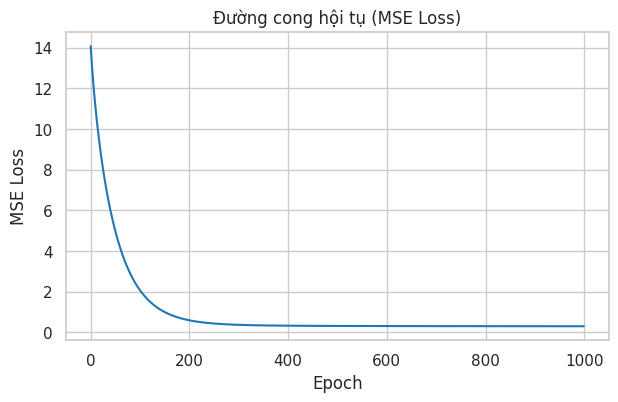

In [26]:
lin_scratch = LinearRegressionScratch(lr=0.01, n_epochs=1000, lam=0.001, verbose=True)
lin_scratch.fit(X_train_s, y_train)

plt.figure(figsize=(7, 4))
plt.plot(lin_scratch.loss_history, color='tab:blue')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Đường cong hội tụ (MSE Loss)")
plt.show()

### 📝 TODO 4.5 - (Phiên bản Hồi quy - Tính $R^2$ Score %):$$R^2 = \left(1 - \frac{\sum (y_{\text{true}} - y_{\text{pred}})^2}{\sum (y_{\text{true}} - \bar{y}_{\text{true}})^2}\right) \times 100\%$$

In [27]:
# TODO 4.5 - Đánh giá mô hình Hồi quy bằng R² Score (%)
def r2_score_percent(y_true, y_pred):
    # ========== BẮT ĐẦU CODE CỦA BẠN ==========
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return (1.0 - ss_res / ss_tot) * 100.0
    # ========== KẾT THÚC CODE CỦA BẠN ==========

In [28]:
# ✅ Kiểm tra
y_t = np.array([10.0, 15.0, 20.0, 25.0])
y_p = np.array([11.0, 14.0, 21.0, 24.0])
print(f"R² Score: {r2_score_percent(y_t, y_p):.2f}%")

R² Score: 96.80%


### Thí nghiệm 4.6 - (Phiên bản Hồi quy tuyến tính - Ảnh hưởng của Learning Rate):

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_1604/3275104196.py:7: RuntimeWarning: overflow encountered in square
  data_loss = (1.0 / (2 * m)) * np.sum((y_pred - Y) ** 2)
/tmp/ipykernel_1604/3275104196.py:11: RuntimeWarning: overflow encountered in square
  reg_loss = (lam / 2.0) * np.sum(W ** 2)


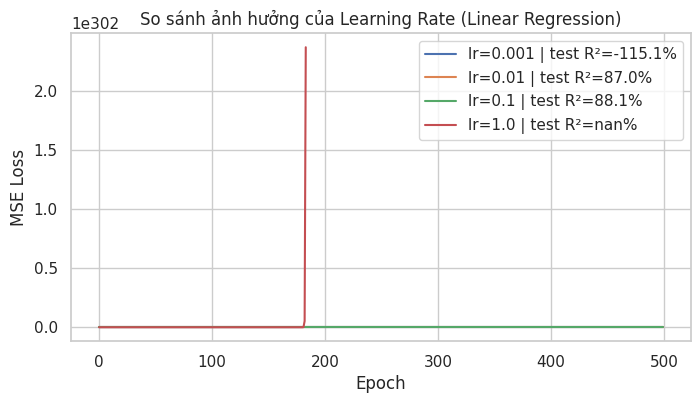

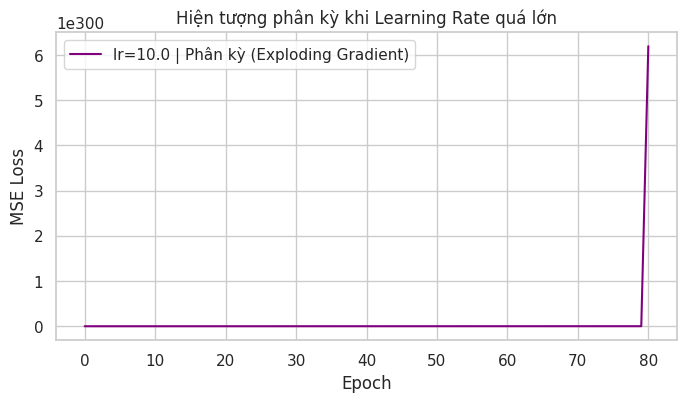

In [29]:
plt.figure(figsize=(8, 4))
for lr in [0.001, 0.01, 0.1, 1.0]:
    m_ = LinearRegressionScratch(lr=lr, n_epochs=500, lam=0.001).fit(X_train_s, y_train)
    r2_val = r2_score_percent(y_test, m_.predict(X_test_s))
    plt.plot(m_.loss_history, label=f"lr={lr} | test R²={r2_val:.1f}%")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("So sánh ảnh hưởng của Learning Rate (Linear Regression)")
plt.show()

# Thử nghiệm phân kỳ khi lr quá lớn (lr = 10.0)
m_div = LinearRegressionScratch(lr=10.0, n_epochs=500, lam=0.001).fit(X_train_s, y_train)
plt.figure(figsize=(8, 4))
plt.plot(m_div.loss_history, label="lr=10.0 | Phân kỳ (Exploding Gradient)", color="purple")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Hiện tượng phân kỳ khi Learning Rate quá lớn")
plt.legend()
plt.show()


In [32]:
# Gọi hàm predict trên tập kiểm tra đã chuẩn hóa X_test_s
y_pred = lin_scratch.predict(X_test_s)

# In ra 5 giá trị dự đoán đầu tiên
print("5 giá trị dự đoán đầu tiên (USD/kg):")
print(y_pred[:5])

5 giá trị dự đoán đầu tiên (USD/kg):
[4.43085662 6.6099294  3.77766872 3.39576292 7.12016629]


In [34]:
# So sánh 5 giá trị dự đoán đầu tiên với giá gốc (y_test)
for i in range(5):
    print(f"Mẫu {i+1}: Dự đoán = {y_pred[i]:.2f} USD/kg | Thực tế (Gốc) = {y_test[i]:.2f} USD/kg")

Mẫu 1: Dự đoán = 4.43 USD/kg | Thực tế (Gốc) = 4.52 USD/kg
Mẫu 2: Dự đoán = 6.61 USD/kg | Thực tế (Gốc) = 6.18 USD/kg
Mẫu 3: Dự đoán = 3.78 USD/kg | Thực tế (Gốc) = 3.89 USD/kg
Mẫu 4: Dự đoán = 3.40 USD/kg | Thực tế (Gốc) = 3.01 USD/kg
Mẫu 5: Dự đoán = 7.12 USD/kg | Thực tế (Gốc) = 5.28 USD/kg


In [ ]:
Mô hình : polynominal regression



```markdown
### 📝 Thiết lập Polynomial Regression
Chúng ta sẽ sử dụng thư viện `scikit-learn` để tự động hóa việc tạo đặc trưng bậc cao và huấn luyện mô hình.
```

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# 1. Lọc ra các cột số quan trọng để tạo đặc trưng đa thức bậc 2 (tránh tạo trên toàn bộ 52 cột gây quá tải)
poly_cols = ['coffee_quality_score', 'flavor_score', 'acidity_score', 'aroma_score']
poly_indices = [feature_names_all.index(col) for col in poly_cols]

# Khởi tạo bộ tạo đa thức bậc 2 (chỉ bao gồm các tương tác bậc 2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# 2. Tạo đặc trưng đa thức cho cả train và test dựa trên các cột đã chọn
X_train_poly_features = poly.fit_transform(X_train_s[:, poly_indices])
X_test_poly_features = poly.transform(X_test_s[:, poly_indices])

# Loại bỏ các cột gốc trùng lặp khi ghép nối lại
X_train_remain = np.delete(X_train_s, poly_indices, axis=1)
X_test_remain = np.delete(X_test_s, poly_indices, axis=1)

# Ghép các đặc trưng đa thức mới với các đặc trưng còn lại (bao gồm cả One-Hot)
X_train_poly = np.hstack((X_train_remain, X_train_poly_features))
X_test_poly = np.hstack((X_test_remain, X_test_poly_features))

print("Kích thước tập Train ban đầu:", X_train_s.shape)
print("Kích thước tập Train sau khi thêm đặc trưng đa thức bậc 2:", X_train_poly.shape)

Kích thước tập Train ban đầu: (28000, 52)
Kích thước tập Train sau khi thêm đặc trưng đa thức bậc 2: (28000, 62)


```markdown
### 3. Huấn luyện mô hình Ridge Regression (Hồi quy tuyến tính có hiệu chỉnh L2) trên tập đặc trưng đa thức mới
```

In [36]:
# Huấn luyện mô hình hồi quy đa thức kết hợp hiệu chỉnh L2 (Ridge) để chống overfitting
poly_model = Ridge(alpha=1.0)
poly_model.fit(X_train_poly, y_train)

# Dự đoán trên tập kiểm tra
y_pred_poly = poly_model.predict(X_test_poly)

# Tính toán điểm R2
r2_poly = r2_score_percent(y_test, y_pred_poly)
print(f"R² Score của mô hình Polynomial Regression: {r2_poly:.2f}%")

# So sánh 5 kết quả đầu tiên với thực tế
print("\nSo sánh 5 giá trị đầu tiên:")
for i in range(5):
    print(f"Mẫu {i+1}: Dự đoán = {y_pred_poly[i]:.2f} USD/kg | Thực tế (Gốc) = {y_test[i]:.2f} USD/kg")

R² Score của mô hình Polynomial Regression: 88.13%

So sánh 5 giá trị đầu tiên:
Mẫu 1: Dự đoán = 4.41 USD/kg | Thực tế (Gốc) = 4.52 USD/kg
Mẫu 2: Dự đoán = 6.60 USD/kg | Thực tế (Gốc) = 6.18 USD/kg
Mẫu 3: Dự đoán = 3.83 USD/kg | Thực tế (Gốc) = 3.89 USD/kg
Mẫu 4: Dự đoán = 3.23 USD/kg | Thực tế (Gốc) = 3.01 USD/kg
Mẫu 5: Dự đoán = 7.04 USD/kg | Thực tế (Gốc) = 5.28 USD/kg


In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. TÍNH TOÁN CÁC CHỈ SỐ ĐÁNH GIÁ (EVALUATION METRICS) ---

# Đối với mô hình Linear Regression (Scratch)
mae_linear = mean_absolute_error(y_test, y_pred)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred))
r2_linear = r2_score_percent(y_test, y_pred)

# Đối với mô hình Polynomial Regression
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score_percent(y_test, y_pred_poly)

print("=== BẢNG SO SÁNH CHI TIẾT HIỆU SUẤT ===")
print(f"{ 'Chỉ số':<25} | { 'Linear Regression':<20} | { 'Polynomial Regression':<20}")
print("-"*73)
print(f"{ 'R² Score (Độ giải thích)':<25} | {r2_linear:18.2f}% | {r2_poly:18.2f}%")
print(f"{ 'MAE (Sai số tuyệt đối)':<25} | {mae_linear:15.3f} USD | {mae_poly:15.3f} USD")
print(f"{ 'RMSE (Độ lệch chuẩn sai số)':<25} | {rmse_linear:15.3f} USD | {rmse_poly:15.3f} USD")

=== BẢNG SO SÁNH CHI TIẾT HIỆU SUẤT ===
Chỉ số                    | Linear Regression    | Polynomial Regression
-------------------------------------------------------------------------
R² Score (Độ giải thích)  |              87.67% |              88.13%
MAE (Sai số tuyệt đối)    |           0.534 USD |           0.527 USD
RMSE (Độ lệch chuẩn sai số) |           0.750 USD |           0.737 USD


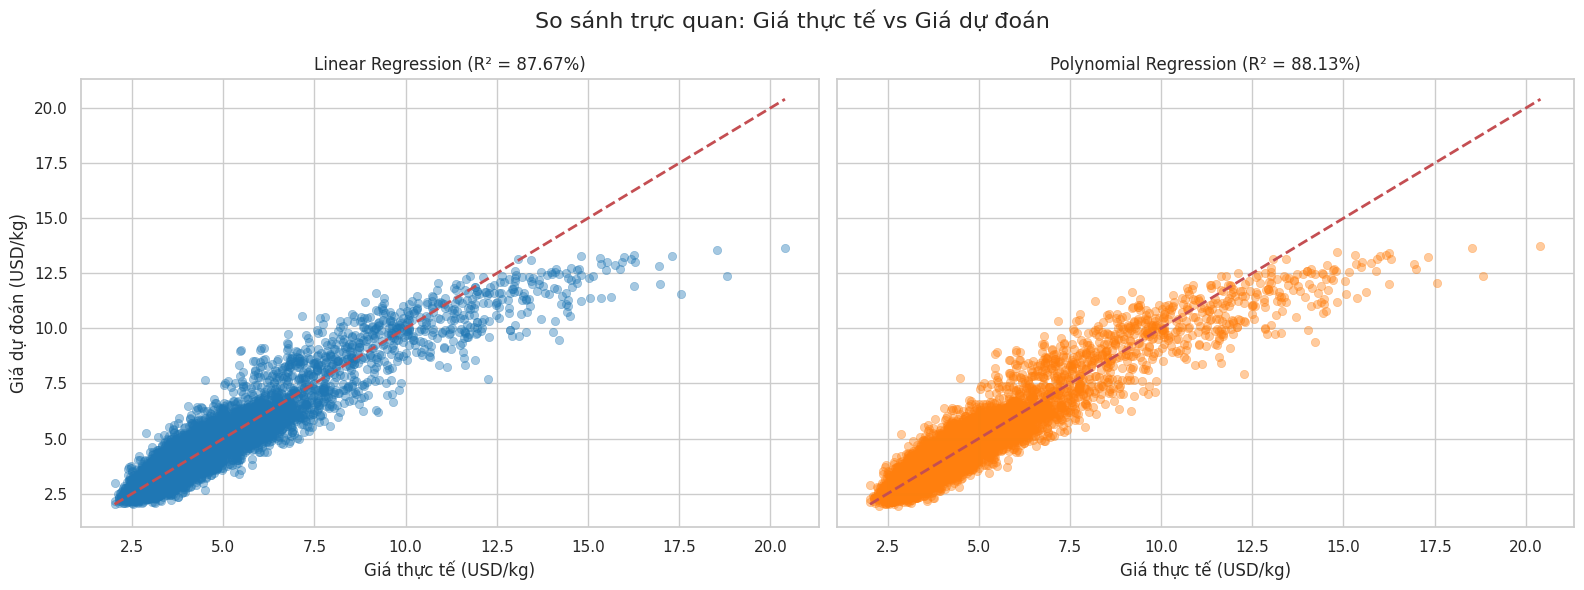

In [38]:
# --- 2. TRỰC QUAN HÓA SO SÁNH --- Minh họa bằng đồ thị Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Biểu đồ cho Linear Regression
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], alpha=0.4, color='tab:blue', edgecolor=None)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f"Linear Regression (R² = {r2_linear:.2f}%)")
axes[0].set_xlabel("Giá thực tế (USD/kg)")
axes[0].set_ylabel("Giá dự đoán (USD/kg)")

# Biểu đồ cho Polynomial Regression
sns.scatterplot(x=y_test, y=y_pred_poly, ax=axes[1], alpha=0.4, color='tab:orange', edgecolor=None)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f"Polynomial Regression (R² = {r2_poly:.2f}%)")
axes[1].set_xlabel("Giá thực tế (USD/kg)")

plt.suptitle("So sánh trực quan: Giá thực tế vs Giá dự đoán", fontsize=16)
plt.tight_layout()
plt.show()